# Project 2: Won't you be my (K-nearest) neighbor?
### Carol Pachar 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier     # to use KNN algorithm provided by sklearn
from sklearn.cluster import KMeans                     # to use KMeans algorithm provided by sklearn 
from sklearn.model_selection import train_test_split   # to split training and testing data 
from sklearn.metrics import accuracy_score

from scipy import stats
from scipy.stats import mode

import time

## Introduction 

In this report, we will be analyzing the MNIST Dataset by using the KNN (K Nearest Neighbor) and the KMeans algorithms. The MNIST dataset consists of $60,000$ images of hand-written images (with each image converted into $28$ x $28$ pixel images) of images as well as labels of what the digit (from $0$ to $9$) is supposed to be. 

The idea behind the K-Nearest Neighbors (or KNN) algorithm is to look at the classifications of the $k$ points nearest to a given location (where $k$ is specified by the user) and pick the most common classification among the K-Nearest Neighbors. It's a supervised learning algorithm, which means that we need to provide it with training and testing data. 

The idea behind the KMeans algorithm is to select $k$ points (centroids), assign each point to the cluster of its nearest centroid, and picks new centroids by evaluating the mean of each cluster. It's an unsupervised learning algorithm, which means that we only need to provide training data (no labels). The algorithm for computing said k means (centroids) is as follows: first, select $k$ points out of the data set and assign them as your initial guess of the cetroids, then assign each data point to the cluster of it's nearest centroid (note that this based on a distance metric like Euclidean distance), then compute new centroids by evaluating the mean of each cluster, and finally, repeat the second and third steps until the centroids stop changing too much.

We will be utilizing the prewritten version of KMeans and KNN in the sklearn module.

## MNIST Dataset

For this project, we will consider the MNIST data set. Ths is a set of 60,000 images of hand written digits (0-9) converted into $28 \times 28$ pixel images.
First, we will import the database.

In [2]:
import csv
File = open('mnist_train.csv')
reader = csv.reader(File)
inside = []
for line in reader:
    inside.append(line)
File.close()
Data = np.array(inside,dtype=int)

In [3]:
Data.shape

(60000, 785)

We have $60,000$ rows (makes sense since there are $60,000$ images). One row per image. As for the $785$, recall that the images are $28 \times 28 (= 784)$, so they've been reshaped into rows of $1 \times 784$ (this is called *vectorization*).

You can visualize this as so: imagine taking each picture ($28$ x $28$ pixels) and cutting up each pixel and forming a flat single line with all the pixels ($784$ pixels in total). This is what we mean by vectorization. Note that the first column is the 'label' column (just to mark row $0$, row $1$, etc.). Hence, we have $785$ columns in total. 

Here, we will store the labels and the pixels in seperate variables. 

In [4]:
number_images = Data[:,1:]
labels = Data[:,0] 

Let's take a look at one of the entries. Say, entry 50 (this number was chosen at random). 

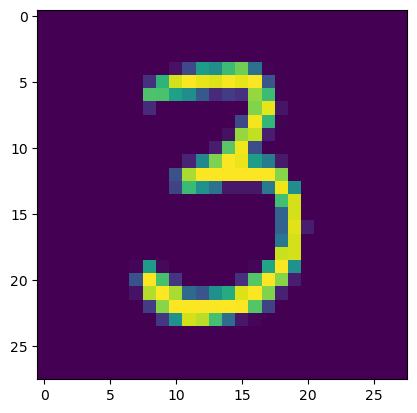

In [5]:
numbers_images = Data[:,1:]
image = number_images[50,:].reshape(28,28)
plt.imshow(image)
plt.show()

Looks like a 3, let's check the label.

In [6]:
labels[50]

np.int64(3)

Here, we will be implementing the KNN (K Nearest Neighbors) and K-Means Clustering algorithms in order to classify hand-written digits. First, we turn to the KNN algorithm. 

## KNN

Here, we will split the MNIST Data into training data and testing data and use KNN to classify the testing data based on the training data and labels. We will observe how the following affects the accuracy of the KNN classification: 

• The value of K

• The size of the training data.

First, we shall split the training and testing data by using the `train_test_split` function from sklearns. 

In [7]:
X_train, X_test, y_train, y_test = train_test_split(numbers_images, labels, test_size=0.9, random_state=42)

Next, we will observe how different values of k affects the model's classification accuracy.

Note that we will be using the `accuracy_score` function. This function computes the accuracy classification score, which is the proportion of correct predictions (either as a fraction or a count) among the total number of samples. It requires the true labels (`y_test`) and the model's predicted labels (`y_predictions`) as input.

In [8]:
for k in [1, 3, 5, 9]:
    MyKNN = KNeighborsClassifier(n_neighbors=k)     # to create the KNN 'calculator' and provide it with different k-values. 
    MyKNN.fit(X_train, y_train)                     # inputting the training data (from train_test_split())
    y_predictions = MyKNN.predict(X_test)           # to predict labels for testing subset (X_test) 
    print("Accuracy for K = {}: {}".format(k, accuracy_score(y_test,y_predictions)))

Accuracy for K = 1: 0.9375555555555556
Accuracy for K = 3: 0.9369259259259259
Accuracy for K = 5: 0.9359814814814815
Accuracy for K = 9: 0.929537037037037


Across all $k$ values ($1$,$3$,$5$,$9$), the prediction accuracy is overall very good with all of these values being over $92$%. The difference in prediction accuracy across all $k$ values is slim with the difference between the least accurate and most accurate value being around $1$%. The $k$ value that gave the most accurate predictions was $k = 1$ with a prediction accuracy of around $93.76$%. The $k$ value that gave the least accurate predictions was $k = 9$ with a prediction accuracy of around $92.95$%.  

From these results, it appears that greater values for $k$ brings less accuracy in prediction. It should be noted that we use small values and that these values have small differences between each other. If we were to use a much larger value for $k$ (say $k = 50$ or $k = 100$), we postulate that the predicition accuracy would drastically decrease. 

Next, we will observe how different sizes of the training data affect the model's classifcation accuracy. 

In [9]:
train_proportions = [0.1, 0.3, 0.5, 0.7, 0.9]                    # to define different training sizes to test (10%, 30%, 50%, 70%, 90%)

for p in train_proportions:
    X_train,X_test,y_train,y_test = train_test_split(number_images,labels,train_size=p,random_state=42) # split testing & training data
                                                                           # this is done for each iteration to change training data size 
    
    MyKNN = KNeighborsClassifier(n_neighbors=4)                  # to create the KNN calculator; we will use 4 neighbors for all trials
    MyKNN.fit(X_train, y_train)                                  # inputting the training data 
    
    # Calculate accuracy on the test set
    predictions = MyKNN.predict(X_test)                          # to predict labels for testing subset (X_test)
    acc = accuracy_score(y_test, predictions)                    # to compare true values w/ predicted values 
    
    print("Training Size: {}% | Accuracy: {}".format(p*100,acc))

Training Size: 10.0% | Accuracy: 0.935037037037037
Training Size: 30.0% | Accuracy: 0.9557380952380953
Training Size: 50.0% | Accuracy: 0.9633
Training Size: 70.0% | Accuracy: 0.9688333333333333
Training Size: 90.0% | Accuracy: 0.9728333333333333


Across all the training sizes that we use ($0.1$,$0.3$,$0.5$,$0.7$,$0.9$), the prediction accuracy is overall very good with all the accuracies being over $93$%. The difference in prediction accuracy across all training sizes is small with the difference between the least accurate and most accurate value being around $4$%. The training size that gave the most accurate prediction was $0.9$ with a prediction accuracy of around $97$%. The training size that gave the least accurarate prediction was $0.1$ with a prediction accuracy of around $93$%.

From these results, it appears that greater training sizes brings better accuracies in predictions. 

We now move on to another algorithm to analyze the MNIST dataset: the KMeans algorithm. 

## KMeans

Here, we will be using the same training and testing datasets that we've used for the KNN algorithm. We will use the K-Means algorithm to split the MNIST images into $10$ clusters. We will be doing the following objectives:  

• Display the centroids to see if they resemble digits. 

• Check how useful the clusters are for classifying images of digits. That is,
check how accurately we can predict which image corresponds to which
digit based on which cluster the image belongs to.

First, we create our KMeans 'calculator'.

In [10]:
MyKMeans = KMeans(n_clusters = 10) # to create the KMeans 'calculator' 

In [11]:
MyKMeans.fit(X_train)         # inputting training data; recall that KMeans is an unsupervised learning algorithm so only X_train is needed

KMeans(n_clusters=10)

Next, we store these $10$ clusters in `centroids`. In order to display the image, we will need to 'reshape' each row (which represents an image) back to its regular $28$ x $28$ image size (for more on this, refer back to the MNIST section of this report). 

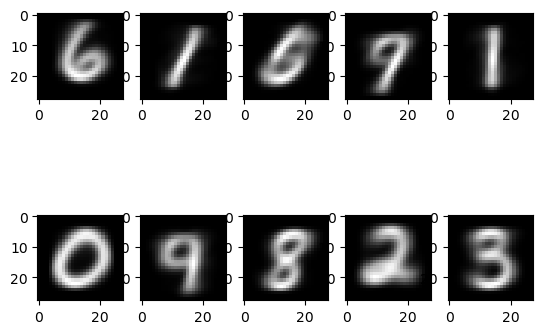

In [12]:
centroids = MyKMeans.cluster_centers_              # storing the array of the 10 centroids in a variable 

for i in range(10):                                # iterating over each centroid (10 in total)
    plt.subplot(2,5,i+1)
    img = centroids[i].reshape(28, 28)             # to reshape the 784 pixels back to 28x28
    plt.imshow(img,'gray')

Based on the images above, we can see that the 10 centroids clearly display digits that fall in the range $0$ to $9$. 

To determine how useful each cluster is in classifying images of digits, we look at which cluster the image belongs to. For example subplot $1$'s image appears to be the number $9$. In this case, cluster $1$'s accuracy in prediction is low since the digit does not match the cluster number. In fact, none of the cluster numbers (the subplot number) match with the digit that's displayed on the image. This would suggest that clusters created with the K-Means algorithm does a poor job of classifying images of digits. We postulate that this is due to the fact that KMeans is an unsupervised learning algorithm, which means that no labels are assigned for each cluster. In simple terms, the algorithm doesn't know what each digit looks like. In short, using the K-Means algorithm for classifying the MNIST data set gives us inaccurate predictions. 

## Using KMeans to Speed Up KNN

An issue with the k-NN algorithm is that it can be slow if we have a big set of
training data. We can try to use K-Means clustering to reduce the amount of
training data. To carry this out, we will do the following: 
1. Split the MNIST images into training and test data.
2. For each digit $0-9$ select all training images corresponding to this digit, and
then use k-means to split these images into several (e.g. $100$) clusters. Use
centroids of these clusters as new training data for k-NN. This will make
the amount of training data smaller since every cluster of the original
training data will be replaced by a single centroid.
3. Investigate how the prediction accuracy and speed of k-NN using this new
training data compares to the case when you use training data without
clustering. Also, if you train k-NN using the centroid training data and
then train it using the same amount of randomly selected training data is
there a difference in the prediction accuracy?

Here, we will be using the same training and testing data sets that were used for both the KMeans and KNN algorithms.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(numbers_images, labels, test_size=0.3, random_state=42)

In [14]:
MyKMeans = KMeans(n_clusters = 100) # to create the KMeans 'calculator' 

In [15]:
MyKMeans.fit(X_train)     # inputting training data; recall that KMeans is an unsupervised learning algorithm so only X_train is needed

KMeans(n_clusters=100)

In [16]:
centroids_100 = MyKMeans.cluster_centers_ # to store the 100 centroids 

Note that before we can use the KNN algorithm, we also need $100$ labels for the $100$ centroids we've created. The `y_train` dataset currently contains the labels of $42,000$ images. In order to create the new `y_train` data (called `new_y_train`), we do the following: 

1. Use KMeans's `predict` function to predict the labels of the original data (`X_train`).
2. Use a for loop to collect $100$ of the most common labels associated with each cluster.
   
   NOTE: I will try to explain what's going on "under the hood": we use the KMeans algorithm on the `X_train` data. The algorithm then selects $42,000$ centroids (since we have $42,000$ images) to create the clusters. At the end, we attempt to predict labels for each of the $42,000$ clusters (this is stored in the `cluter_labels` variable).
   Then, the for-loop is used to iterate over $100$ clusters (from the $42,000$ clusters) and collects the labels of all the points that are inside each cluster. Next, we search for the most common label inside the cluster (this is stored in `common_label`). 
     
4. Add each label to the `new_y_train` list and convert it to an array.

Here, we use the function `mode()` from the scipy module. This is used to calculate the mode (the most common label) of each cluster. We need to provide it with an array of elements (to search for the mode). The `keepdims` parameter serves as an option to retain the axis dimension after the operation. 

In [17]:
cluster_labels = MyKMeans.predict(X_train)    # to get labels of each cluster (42,000 total) of X_train 
new_y_train = []                              # to store the most common label of each cluster (NOTE: will contain a total of 100 labels) 

for i in range(100):
    labels_in_cluster = y_train[cluster_labels == i]              # to collect all labels of each point of cluster  
    
    common_label = mode(labels_in_cluster, keepdims=True).mode[0] # to find most common label inside of cluster
    new_y_train.append(common_label)

new_y_train = np.array(new_y_train)           # converting n_y_train to an array so KNN can process it

Now that we have the appropriate `X_train` (`centroids_100`) and `y_train` (`new_y_train`) data, we can finally implement the KNN algorithm with the clustered training data. 

In [18]:
start_time = time.perf_counter()                # starting timer
MyKNN = KNeighborsClassifier(n_neighbors=3)     # to create the KNN 'calculator'
MyKNN.fit(centroids_100,new_y_train)            # inputting the training data
y_predictions = MyKNN.predict(X_test)           # to predict labels for testing subset (X_test)
print("Accuracy for K = 3: {}".format(accuracy_score(y_test,y_predictions)))
end_time = time.perf_counter()                  # ending timer 
elapsed_time = end_time - start_time 
print("Elapsed Time: {} seconds".format(elapsed_time))

Accuracy for K = 3: 0.8248888888888889
Elapsed Time: 0.4097702079998271 seconds


Below, we use the KNN algorithm without clustering the training data. 

In [19]:
start_time = time.perf_counter()                # starting timer
MyKNN = KNeighborsClassifier(n_neighbors=3)     # to create the KNN 'calculator' and provide it with different k-values. 
MyKNN.fit(X_train, y_train)                     # inputting the training data (from train_test_split())
y_predictions = MyKNN.predict(X_test)           # to predict labels for testing subset (X_test)
print("Accuracy for K = 3: {}".format(accuracy_score(y_test,y_predictions)))
end_time = time.perf_counter()                  # ending timer 
elapsed_time = end_time - start_time 
print("Elapsed Time: {} seconds".format(elapsed_time))

Accuracy for K = 3: 0.9701111111111111
Elapsed Time: 23.53715391700098 seconds


In both cases, when the KNN algorithm is applied (with $k = 3$ for both cases), we see that while the first case has a much faster speed of around $0.5$ seconds, the accuracy in classication declines to around $82$%. Meanwhile, case $2$ boasts a higher accuracy of around $97$% while its speed is at around $24$ seconds. These results suggest that while applying KMeans on the training data (which is then used for KNN) boosts the speed of the KNN algorithm, it also reduces KNN's accuracy of classsifcation. 

Now, we're going to train k-NN using $100$ randomly selected training data so that we can see if there is any difference in the prediction accuracy between using this dataset and using the centroid data. 

First, we split the training and testing data. Note that since we only want $100$ randomly selected values for the `X_train` data we would need to adjust the `test_size` to $\frac{599}{600}$ or around $0.998333333333$. 

In [20]:
X_train_100vals, X_test, y_train_100vals, y_test = train_test_split(numbers_images, labels, test_size=0.99833, random_state=42)

In [21]:
MyKNN = KNeighborsClassifier(n_neighbors=3)     # to create the KNN 'calculator' and provide it with different k-values. 
MyKNN.fit(X_train_100vals, y_train_100vals)     # inputting the training data (from train_test_split())
y_predictions = MyKNN.predict(X_test)           # to predict labels for testing subset (X_test) 
print("Accuracy for K = 3: {}".format(accuracy_score(y_test,y_predictions)))

Accuracy for K = 3: 0.6434891485809683


When the KNN algorithm is given the centroid data as its `X_train` dataset, the accuracy in classification was at around $82$%. If we give the algorithm $100$ randolmy selected values for its `X_train` data, the accuracy in classication is around $64$%. In this case, between the two datasets, utilizing the centroid data gives us more accuracy in classification. 

## Conclusion 

This section should summarize your results and major findings. It can also
include potential future extensions of the project. This should be the last section
of the report.

In this report, we analyzed the MNIST Dataset by using the KNN (K Nearest Neighbor) and the KMeans algorithms. 

When using the KNN algorithm, we found a trend in the size of $k$ values and its effect on the model's prediction accuracies: greater values for $k$ brings less accuracy in prediction. We also detected a trend in training data size and its effect on the model's prediction accuracies: greater training sizes brings better accuracies in predictions. 

When using the KMeans algorithm, we saw that the centroids did resemble digits, but none of the cluster numbers (the subplot number) matched with the digit that's displayed on the image. This would suggest that using the KMeans algorithm for classifying the MNIST data set gives us inaccurate predictions. 

Finally, we implemented the KNN algorithm by using two different training data: the $100$ centroids, which were split by KMeans, and the original `X_train` (not clustered) data. The results suggest that while applying KMeans on the training data boosts the speed of the KNN algorithm, it also reduces KNN's accuracy of classsifcation. We also tested the prediction accuracies of KNN between using the $100$ centroids as training data as well as $100$ randomly selected values as its training data. The results suggest that utilizing the $100$ centroid data gives us better prediction accuracy. 

In the future, I would love to expand this project further by exploring the KNN algorithm even further, specifically what would happen if another metric (distance) were used besides the Euclidean distance. I would also consider a weighted KNN algorithm. Would any of these changes enhance or diminish prediction accuracy?  